/tmp/ipykernel_3438924/3978577471.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(df["time_s"], df["rate_limit"].fillna(method="ffill"), marker="s", linewidth=2, label="rate_limit")


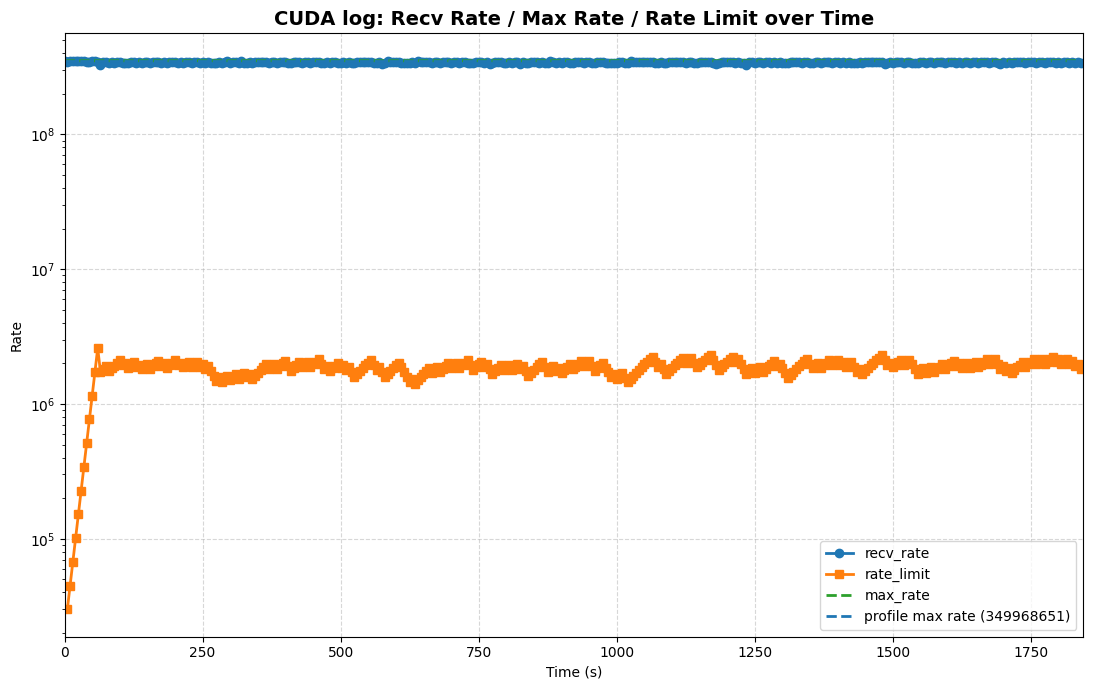

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import dedent

# ---------- Helpers ----------
triplet_pat = re.compile(
    r"recv_rate:\s*([0-9.]+),\s*max_rate:\s*([0-9.]+)(?:,\s*rate_limit:\s*([0-9.]+))?"
)
profile_pat = re.compile(r"profile max rate:\s*([0-9.]+)", re.IGNORECASE)

def parse_log_text(text: str):
    rows = []
    profile_max = None
    for line in text.splitlines():
        m = triplet_pat.search(line)
        if m:
            recv_rate = float(m.group(1))
            max_rate = float(m.group(2))
            rate_limit = float(m.group(3)) if m.group(3) is not None else None
            rows.append({"recv_rate": recv_rate, "max_rate": max_rate, "rate_limit": rate_limit})
        pm = profile_pat.search(line)
        if pm:
            try:
                profile_max = float(pm.group(1))
            except:
                pass
    df = pd.DataFrame(rows)
    return df, profile_max

def parse_log_file(path: str):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    return parse_log_text(text)

# ---------- Try to read user's file; fallback to the snippet they pasted ----------
file_path = "cudalog"  # adjust if needed
if os.path.exists(file_path):
    text_source = open(file_path, "r", encoding="utf-8", errors="ignore").read()
    source_desc = f"Parsed from file: {os.path.abspath(file_path)}"
else:
    # fallback to parse the snippet user posted so charts still render
    text_source = dedent("""
    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/loader.c:781 Start hijacking
    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/loader.c:796 can't find function cuEGLInit in libcuda.so.570.133.20
    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:93 list_head: 0x65b1310

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:459 [0] recv_rate: 351080764.00, max_rate: 349968651.00

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:461 profile max rate: 349968651

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 344312033.00, max_rate: 351669404.00, rate_limit: 30001

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 351216850.00, max_rate: 351669404.00, rate_limit: 45002

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 350706848.00, max_rate: 351669404.00, rate_limit: 67504

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 349726597.00, max_rate: 351669404.00, rate_limit: 101257

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 350736553.00, max_rate: 351669404.00, rate_limit: 151886

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 348477913.00, max_rate: 351669404.00, rate_limit: 227830

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 349928527.00, max_rate: 351669404.00, rate_limit: 341746

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 346661182.00, max_rate: 351669404.00, rate_limit: 512620

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 346950888.00, max_rate: 351669404.00, rate_limit: 768931

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 347848397.00, max_rate: 351669404.00, rate_limit: 1153397

    /home/haibin/cxsj_25fall/TGS-GPU-kernel/hijack/src/low_priority_hijack_call.c:528 [0] recv_rate: 349004341.00, max_rate: 351669404.00, rate_limit: 1730096
    """).strip()
    source_desc = "Parsed from the snippet you pasted (upload cudalog for file parsing)."

# Parse
df, profile_max = parse_log_text(text_source)

# Keep only rows where at least recv/max were captured
df.reset_index(drop=True, inplace=True)

# Add time column: the steady samples (with rate_limit present) are 5s apart.
# We'll assume every parsed row is a 5s tick; if you prefer, we can infer gaps from timestamps in future.
df["time_s"] = df.index * 5

# Save CSV
out_csv = "./cudalog_parsed.csv"
df.to_csv(out_csv, index=False)

# Plot 1: rates over time
plt.figure(figsize=(11, 7))
plt.plot(df["time_s"], df["recv_rate"], marker="o", linewidth=2, label="recv_rate")
# Plot rate_limit only where present
if df["rate_limit"].notna().any():
    plt.plot(df["time_s"], df["rate_limit"].fillna(method="ffill"), marker="s", linewidth=2, label="rate_limit")
plt.plot(df["time_s"], df["max_rate"], linestyle="--", linewidth=2, label="max_rate")
# Optional profile max line
if profile_max is not None:
    plt.axhline(profile_max, linestyle="--", linewidth=2, label=f"profile max rate ({profile_max:.0f})")
plt.xlabel("Time (s)")
plt.ylabel("Rate")
plt.title("CUDA log: Recv Rate / Max Rate / Rate Limit over Time", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best")
plt.tight_layout()

# log y
plt.yscale("log")

# lim x 0, 1750
plt.xlim(0, df["time_s"].max() + 5)

out_png = "./cudalog_plot.png"
plt.savefig(out_png, bbox_inches="tight", dpi=220)
plt.show()

# Show a quick head of the parsed data
# from caas_jupyter_tools import display_dataframe_to_user
# display_dataframe_to_user("Parsed CUDA Log (first rows)", df.head(12))

# Report context variables for user visibility
# profile_max, source_desc, out_csv
